In [1]:
!mamba install pandas numpy matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 4.851300000011921 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [8]:
#Question 10
import numpy as np

prices = np.array([
    [100,108,103,115,110,119,125,121,130,127,135,140],  # Stock A
    [200,195,210,205,220,215,225,230,222,235,240,238]   # Stock B
])    

# (a) Monthly Simple Returns
#Using Rt=(Pt-Pt-1)/Pt-1
returns = (prices[:,1:] - prices[:,:-1]) / prices[:,:-1] #prices[:,1:] → all columns except first, prices[:,:-1] → all columns except last
print("Monthly Returns:")
print(returns)
print("\nShape of returns matrix:")
print(returns.shape) #Result shape:(2,11) because 2 stocks and 11 monthly returns from 12 prices

# (b) Annualised Mean Return and Standard Deviation
monthly_mean = np.mean(returns, axis=1)
monthly_std = np.std(returns, axis=1, ddof=1)
annualised_mean = monthly_mean * 12 #Mean annual return:μannual=12×μmonthly
annualised_std = monthly_std * np.sqrt(12) #Annualised volatility:σannual=12×σmonthly
print("\nAnnualised Mean Returns:")
print(annualised_mean)
print("\nAnnualised Standard Deviations:")
print(annualised_std)

# (c) Covariance Matrix
"""np.cov(returns) computes:Σ=[σA**2 Cov(A,B)
                               Cov(A,B) σB**2]"""
cov_matrix = np.cov(returns)
print("\nCovariance Matrix:")
print(cov_matrix)
# Correlation
#Cov(A,B)=ρσAσB
corr_matrix = np.corrcoef(returns)
rho = corr_matrix[0,1]
sigma_A = monthly_std[0]
sigma_B = monthly_std[1]
check_value = rho * sigma_A * sigma_B
print("\nOff-diagonal covariance from matrix:")
print(cov_matrix[0,1])
print("\nρ * σA * σB:")
print(check_value)

Monthly Returns:
[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]

Shape of returns matrix:
(2, 11)

Annualised Mean Returns:
[0.39087388 0.20073826]

Annualised Standard Deviations:
[0.20199403 0.14582022]

Covariance Matrix:
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]

Off-diagonal covariance from matrix:
-0.0020642605060094284

ρ * σA * σB:
-0.0020642605060094284


In [3]:
#Question 11
import numpy as np
# Asset Parameters
mu = np.array([0.15, 0.08, 0.05])
Sigma = np.array([
    [0.0625, 0.012,   0.001],
    [0.012,  0.0144,  0.00096],
    [0.001,  0.00096, 0.0016]
])

# (a) Equal Weight Portfolio
w = np.array([1/3, 1/3, 1/3])
portfolio_return = w @ mu
portfolio_variance = w @ Sigma @ w
portfolio_std = np.sqrt(portfolio_variance)
print("Portfolio Expected Return:")
print(portfolio_return)
print("\nPortfolio Variance:")
print(portfolio_variance)
print("\nPortfolio Standard Deviation:")
print(portfolio_std)

# (b) Generate 10,000 Random Portfolios
num_portfolios = 10000
weights = np.random.dirichlet(np.ones(3), size=num_portfolios) #np.random.dirichlet() generates random weights summing to 1.

# Portfolio returns
portfolio_returns = weights @ mu

# Portfolio variances
portfolio_variances = np.einsum('ij,jk,ik->i', weights, Sigma, weights) #Computes vectorised variance all at once

portfolio_stds = np.sqrt(portfolio_variances)
print("\nShape of Returns Array:")
print(portfolio_returns.shape)
print("\nShape of Std Array:")
print(portfolio_stds.shape)

# (c) Sharpe Ratios
Rf = 0.04
sharpe_ratios = (portfolio_returns - Rf) / portfolio_stds
max_index = np.argmax(sharpe_ratios)
print("\nMaximum Sharpe Ratio:")
print(sharpe_ratios[max_index])
print("\nWeights for Maximum Sharpe Portfolio:")
print(weights[max_index])
print("\nReturn of Maximum Sharpe Portfolio:")
print(portfolio_returns[max_index])
print("\nRisk of Maximum Sharpe Portfolio:")
print(portfolio_stds[max_index])

Portfolio Expected Return:
0.09333333333333332

Portfolio Variance:
0.011824444444444443

Portfolio Standard Deviation:
0.10874026137748816

Shape of Returns Array:
(10000,)

Shape of Std Array:
(10000,)

Maximum Sharpe Ratio:
0.505281901068225

Weights for Maximum Sharpe Portfolio:
[0.19903971 0.18361333 0.61734696]

Return of Maximum Sharpe Portfolio:
0.07541237085274234

Risk of Maximum Sharpe Portfolio:
0.07008438413858967


Shape of σp array:
(200,)

ρ at minimum σp:
-1.0

Minimum σp:
0.08000000000000002


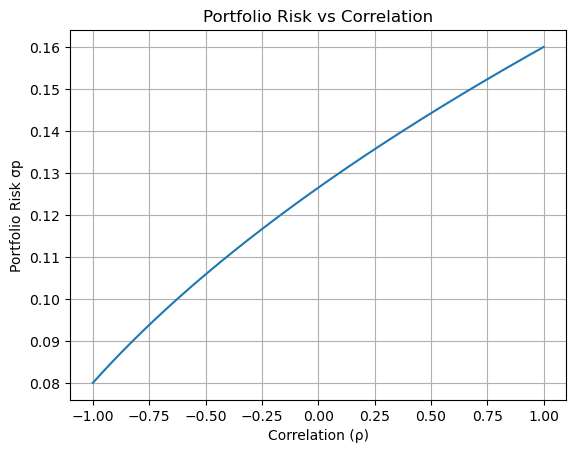

In [4]:
#Question 12
import numpy as np
import matplotlib.pyplot as plt
# Parameters
mu1 = 0.12
sigma1 = 0.20
mu2 = 0.06
sigma2 = 0.10
w1 = 0.6
w2 = 1 - w1


# (a) Correlation Array
rho = np.linspace(-1, 1, 200)
portfolio_variance = (
    (w1**2)*(sigma1**2)
    + (w2**2)*(sigma2**2)
    + 2*w1*w2*rho*sigma1*sigma2
)
portfolio_std = np.sqrt(portfolio_variance)
print("Shape of σp array:")
print(portfolio_std.shape)


# (b) Minimum Risk
min_index = np.argmin(portfolio_std)
min_rho = rho[min_index]
min_sigma = portfolio_std[min_index]
print("\nρ at minimum σp:")
print(min_rho)
print("\nMinimum σp:")
print(min_sigma)


# (c) Analytical Plot
plt.plot(rho, portfolio_std)
plt.xlabel("Correlation (ρ)")
plt.ylabel("Portfolio Risk σp")
plt.title("Portfolio Risk vs Correlation")
plt.grid(True)
plt.show()

In [5]:
#Question 13
import pandas as pd
import numpy as np
# Simulated Data
np.random.seed(0)
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52,4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL','MSFT','GOOGL','AMZN']
)
print(df.head())


# (a) Weekly Returns
returns_df = df.pct_change().dropna() #Computes Rt = (Pt-Pt-1)/Pt-1
print("\nFirst 3 Rows:")
print(returns_df.head(3))
print("\nShape:")
print(returns_df.shape)


# (b) Describe
desc = returns_df.describe()
print("\nDescriptive Statistics:")
print(desc)
highest_mean = returns_df.mean().idxmax()
highest_std = returns_df.std().idxmax()
print("\nHighest Mean Return:")
print(highest_mean)
print("\nHighest Standard Deviation:")
print(highest_std)


# (c) Sharpe Ratios
Rf = 0.02
annual_return = returns_df.mean() * 52
annual_std = returns_df.std() * np.sqrt(52)
sharpe = (annual_return - Rf) / annual_std
print("\nAnnualised Sharpe Ratios:")
print(sharpe)

                  AAPL        MSFT       GOOGL        AMZN
2023-01-02  107.356209  101.400472  102.057476  105.752233
2023-01-09  115.698036   98.630379  104.098806  105.510702
2023-01-16  115.567441  100.042565  104.502800  109.505004
2023-01-23  119.432191  100.607830  105.535002  110.582737
2023-01-30  126.928133  100.189830  106.301329  108.387405

First 3 Rows:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

Shape:
(51, 4)

Descriptive Statistics:
            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.0094

In [6]:
#Question 14
import pandas as pd
import numpy as np


# (a) Correlation Matrix
corr_matrix = returns_df.corr() #Computes pairwise correlations
print("Correlation Matrix:")
print(corr_matrix)
# Find lowest correlation pair
corr_unstack = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack()
lowest_pair = corr_unstack.idxmin()
lowest_value = corr_unstack.min()
print("\nLowest Correlation Pair:")
print(lowest_pair)
print("\nLowest Correlation Value:")
print(lowest_value)


# (b) Equal Weight Portfolio
weights = pd.Series(
    [0.25,0.25,0.25,0.25],
    index=['AAPL','MSFT','GOOGL','AMZN']
)
portfolio_returns = returns_df.dot(weights)
print("\nPortfolio Return Series:")
print(portfolio_returns.head())


# (c) Monthly Resampling
monthly_returns = portfolio_returns.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
)
print("\nMonthly Returns:")
print(monthly_returns)
print("\nMean Monthly Return:")
print(monthly_returns.mean())
print("\nStd Monthly Return:")
print(monthly_returns.std())

Correlation Matrix:
           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

Lowest Correlation Pair:
('AAPL', 'MSFT')

Lowest Correlation Value:
-0.07532396170747635

Portfolio Return Series:
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64

Monthly Returns:
2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
2023-06-30    0.051925
2023-07-31    0.084694
2023-08-31    0.012007
2023-09-30    0.008753
2023-10-31    0.021548
2023-11-30   -0.049706
2023-12-31    0.026272
Freq: ME, dtype: float64

Mean Monthly Return:
0.013974973306651484

Std Monthly Return:
0.039023369077949295


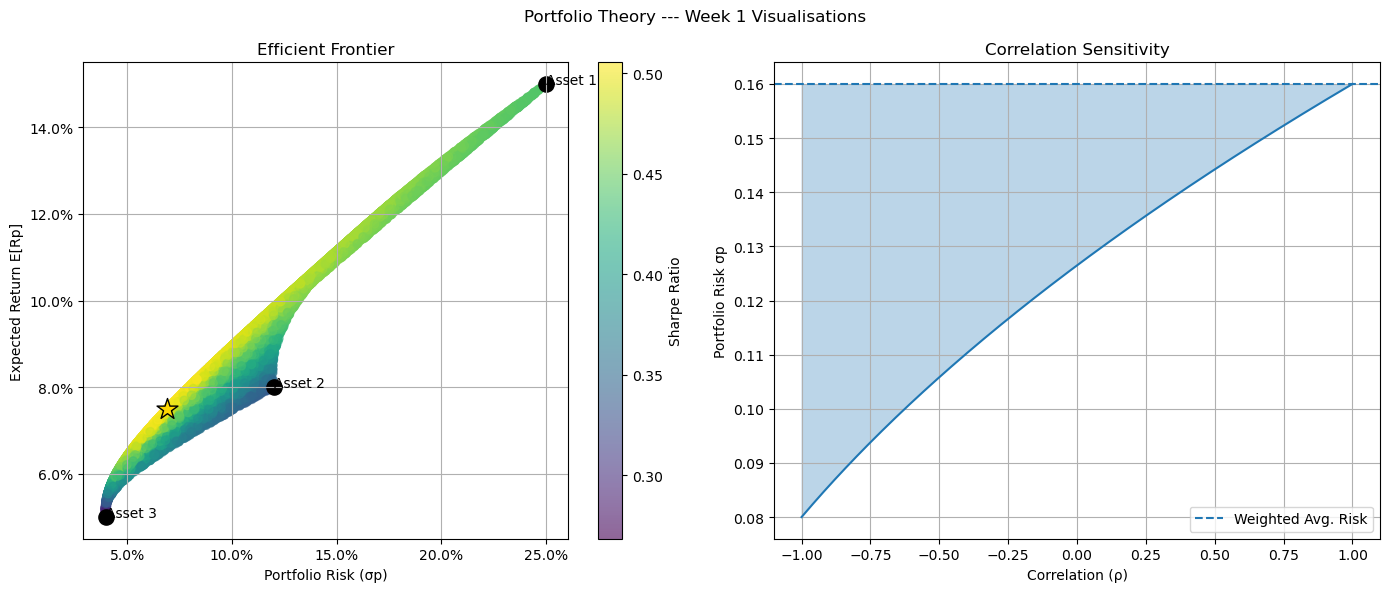

In [7]:
#Question 15
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
# 3-Asset Universe
mu = np.array([0.15, 0.08, 0.05])
Sigma = np.array([
    [0.0625, 0.012,   0.001],
    [0.012,  0.0144,  0.00096],
    [0.001,  0.00096, 0.0016]
])
Rf = 0.04
# Simulate 20,000 Portfolios
num_portfolios = 20000
weights = np.random.dirichlet(np.ones(3), size=num_portfolios)
portfolio_returns = weights @ mu
portfolio_variances = np.einsum(
    'ij,jk,ik->i',
    weights,
    Sigma,
    weights
)
portfolio_std = np.sqrt(portfolio_variances)
sharpe_ratios = (portfolio_returns - Rf) / portfolio_std
# Maximum Sharpe Portfolio
max_idx = np.argmax(sharpe_ratios)
max_return = portfolio_returns[max_idx]
max_std = portfolio_std[max_idx]
# Individual Assets
asset_std = np.sqrt(np.diag(Sigma))
asset_returns = mu
labels = ['Asset 1', 'Asset 2', 'Asset 3']
# Correlation Sensitivity
sigma1 = 0.20
sigma2 = 0.10
w1 = 0.6
w2 = 0.4
rho = np.linspace(-1,1,200)
sigma_p = np.sqrt(
    (w1**2)*(sigma1**2)
    + (w2**2)*(sigma2**2)
    + 2*w1*w2*rho*sigma1*sigma2
)
weighted_avg_risk = w1*sigma1 + w2*sigma2
# Plotting
fig, axes = plt.subplots(1,2, figsize=(14,6))

# Subplot 1
sc = axes[0].scatter(
    portfolio_std,
    portfolio_returns,
    c=sharpe_ratios,
    cmap='viridis',
    alpha=0.6
)
# Max Sharpe
axes[0].scatter(
    max_std,
    max_return,
    marker='*',
    s=250,
    color='gold',
    edgecolor='black',
    label='Max Sharpe'
)
# Individual assets
axes[0].scatter(
    asset_std,
    asset_returns,
    color='black',
    s=120
)
for i in range(3):
    axes[0].annotate(
        labels[i],
        (asset_std[i], asset_returns[i])
    )
axes[0].set_xlabel("Portfolio Risk (σp)")
axes[0].set_ylabel("Expected Return E[Rp]")
axes[0].set_title("Efficient Frontier")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].grid(True)
cbar = fig.colorbar(sc, ax=axes[0])
cbar.set_label("Sharpe Ratio")


# Subplot 2
axes[1].plot(rho, sigma_p)
axes[1].axhline(
    weighted_avg_risk,
    linestyle='--',
    label='Weighted Avg. Risk'
)
axes[1].fill_between(
    rho,
    sigma_p,
    weighted_avg_risk,
    where=(sigma_p < weighted_avg_risk),
    alpha=0.3
)
axes[1].set_xlabel("Correlation (ρ)")
axes[1].set_ylabel("Portfolio Risk σp")
axes[1].set_title("Correlation Sensitivity")
axes[1].legend()
axes[1].grid(True)
# Global Settings
fig.suptitle("Portfolio Theory --- Week 1 Visualisations")
plt.tight_layout()
plt.savefig("week1_plots.png", dpi=150)
plt.show()